In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.getcwd()

'/Users/shankernarayan/Documents/Project_Datasets/payday_loans'

# Preview loans table and extract payday loan data

##### I downloaded the CFPB complaint data from the link below

[CFPB Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/search/?dateRange=All&date_received_max=2026-05-18&date_received_min=2011-12-01&page=1&searchField=all&size=25&sort=created_date_desc&tab=List)

##### I added the following 'Product/sub-product' filters before downloading, and saved file as 'cfpb_payday_daya.csv'

1. Payday loan
2. Payday loan, title loan, or personal loan
3. Payday loan, title loan, or personal loan, or advance loan

In [3]:
loans = pd.read_csv('/Users/shankernarayan/Documents/Project_Datasets/payday_loans/cfpb_payday_data.csv')

##### Products in loans table

In [4]:
loans['Sub-product'].value_counts()

Sub-product
Installment loan                         30304
Personal line of credit                  13057
Payday loan                              11794
Title loan                                4874
Other advances of future income            608
Earned wage access                         299
Pawn loan                                  186
Tax refund anticipation loan or check       56
Name: count, dtype: int64

##### 'loans' contains data between 2013 and 2026. Notable spike in overall complaints in 2025

In [8]:
loans['Date received'].dt.year.value_counts().sort_index()

Date received
2013      194
2014     1703
2015     1576
2016     1562
2017     3431
2018     4361
2019     4318
2020     4200
2021     4352
2022     5771
2023     7244
2024     9036
2025    13123
2026     5869
Name: count, dtype: int64

##### Convert date columns to 'datetime', complaint ID to string

In [7]:
loans['Date received'] = pd.to_datetime(loans['Date received'])
loans['Date sent to company'] = pd.to_datetime(loans['Date sent to company'])
loans['Complaint ID'] = loans['Complaint ID'].astype(object)

/var/folders/q6/5f0g3wq12rb01y9j0hw2f1d00000gn/T/ipykernel_65025/1089682607.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loans['Date received'] = pd.to_datetime(loans['Date received'])
/var/folders/q6/5f0g3wq12rb01y9j0hw2f1d00000gn/T/ipykernel_65025/1089682607.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loans['Date sent to company'] = pd.to_datetime(loans['Date sent to company'])


In [9]:
loans.info() #data types look good after converting 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66740 entries, 0 to 66739
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 66740 non-null  datetime64[ns]
 1   Product                       66740 non-null  object        
 2   Sub-product                   61178 non-null  object        
 3   Issue                         66740 non-null  object        
 4   Sub-issue                     6394 non-null   object        
 5   Consumer complaint narrative  35021 non-null  object        
 6   Company public response       17158 non-null  object        
 7   Company                       66740 non-null  object        
 8   State                         65966 non-null  object        
 9   ZIP code                      66094 non-null  object        
 10  Tags                          12615 non-null  object        
 11  Consumer consent provided?  

##### Create new dataframe for ONLY payday loans complaints b/w 2023 and 2026

In [10]:
payday = loans[(loans['Sub-product'] == "Payday loan") & 
              loans['Date received'].dt.year.between(2023, 2026)]
payday.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
12,2026-03-31,"Payday loan, title loan, personal loan, or adv...",Payday loan,Money was taken from your bank account on the ...,NaN,NaN,NaN,"Dave Operating, LLC",WV,260XX,NaN,NaN,Web,2026-03-31,Closed with explanation,Yes,NaN,20807475
13,2025-07-17,"Payday loan, title loan, personal loan, or adv...",Payday loan,Problem with fraud alerts or security freezes,NaN,They are constantly trying to make negative re...,NaN,"EGL US, LLC",IL,60637,Servicemember,Consent provided,Web,2025-07-17,Closed with explanation,Yes,NaN,14719737
21,2025-12-07,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,They charged me XXXX XXXX XXXX which is more t...,Company has responded to the consumer and the ...,"CreditNinja Lending, LLC",TX,76904,NaN,Consent provided,Web,2025-12-07,Closed with explanation,Yes,NaN,17814736
26,2026-03-18,"Payday loan, title loan, personal loan, or adv...",Payday loan,Charged fees or interest you didn't expect,NaN,I am submitting this complaint regarding a loa...,Company has responded to the consumer and the ...,QC HOLDINGS INC,FL,32536,Servicemember,Consent provided,Web,2026-03-18,Closed with explanation,Yes,NaN,20356925
41,2023-10-01,"Payday loan, title loan, personal loan, or adv...",Payday loan,Incorrect information on your report,Account information incorrect,NaN,NaN,"Spring Oaks Capital, LLC",GA,30337,NaN,Consent not provided,Web,2023-10-01,Closed with explanation,Yes,NaN,7626438


# Breakdown of complaints by issue

### Five issues accounted for over 70% of complaints


1. Charged fees or interest you didn't expect (27.9%)
2. Struggling to pay your loan (17.3%)
3. Received a loan you didn't apply for (11.0%)
4. Can't stop withdrawals from your bank account (8.8%)
5. Can't contact lender or servicer (6.3%)
###### Total: 71.3%

In [11]:
(payday.Issue.value_counts(normalize=True) * 100).round(2).astype(str) + "%"

Issue
Charged fees or interest you didn't expect                                          27.88%
Struggling to pay your loan                                                         17.29%
Received a loan you didn't apply for                                                10.91%
Can't stop withdrawals from your bank account                                         8.8%
Problem with the payoff process at the end of the loan                               6.68%
Can't contact lender or servicer                                                     6.31%
Money was taken from your bank account on the wrong day or for the wrong amount      5.51%
Loan payment wasn't credited to your account                                         4.43%
Was approved for a loan, but didn't receive the money                                4.37%
Incorrect information on your report                                                 4.02%
Improper use of your report                                                         

# YoY increase in payday loan complaints

In [12]:
years = payday["Date received"].dt.year.value_counts().sort_index().reset_index()
years

,Date received,count
0,2023,1208
1,2024,1356
2,2025,2271
3,2026,792


##### We only have data for half of 2026, 

# Complaint concentration by company

### 480 unique companies named in dataset

In [13]:
company_counts = payday["Company"].value_counts()
total = payday.shape[0]
total_companies = company_counts.shape[0]

thresholds = [5, 24, 48, 120, 240, 360, 480]

rows = []
for n in thresholds:
    complaint_share = company_counts.head(n).sum() / total
    company_share = n / total_companies
    rows.append({
        "Top N Companies": n,
        "% of All Companies": f"{company_share:.1%}",
        "% of All Complaints": f"{complaint_share:.1%}"
    })

pd.DataFrame(rows)

,Top N Companies,% of All Companies,% of All Complaints
0,5,1.0%,19.8%
1,24,5.0%,52.1%
2,48,10.0%,68.5%
3,120,25.0%,87.0%
4,240,50.0%,95.0%
5,360,75.0%,97.9%
6,480,100.0%,100.0%


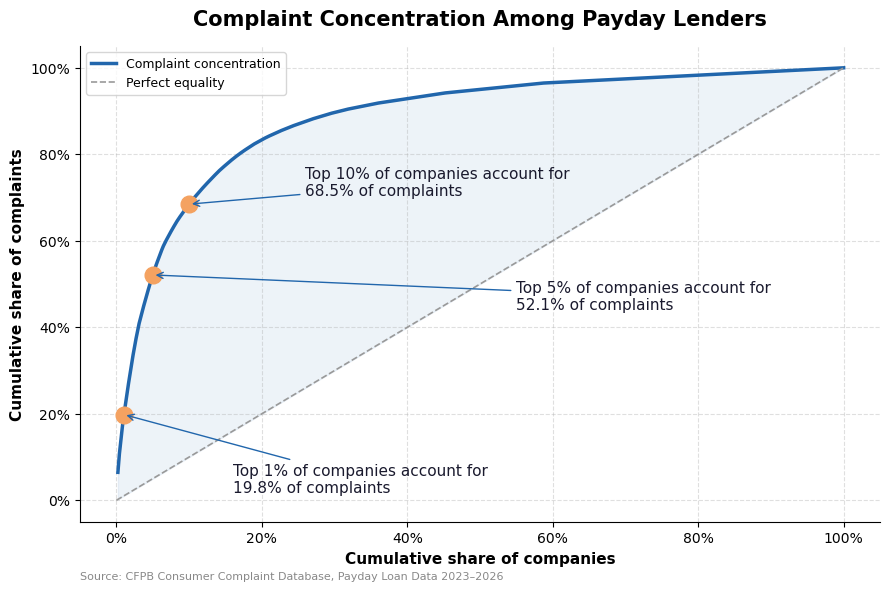

In [14]:
import matplotlib.ticker as mtick

## Number of complaints recorded against each company
company_counts = payday["Company"].value_counts().reset_index()
company_counts.columns = ["Company", "Count"]
company_counts = company_counts.sort_values("Count", ascending=False)

## create an array 
cum_companies = np.arange(1, len(company_counts) + 1) / len(company_counts)
cum_complaints = company_counts["Count"].cumsum() / company_counts["Count"].sum()

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(cum_companies, cum_complaints, color="#2166ac", linewidth=2.5, label="Complaint concentration")
ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1.2, label="Perfect equality")
ax.fill_between(cum_companies, cum_complaints, cum_companies, alpha=0.08, color="#2166ac")

# Annotation lines for key thresholds

annotations = [
    (0.01, "1%", (0.15, -0.18)),
    (0.05, "5%", (0.5, -0.08)),
    (0.10, "10%", (0.16, 0.02)),
]

for x_val, label, (x_offset, y_offset) in annotations:
    idx = np.searchsorted(cum_companies, x_val)
    y_val = cum_complaints[idx]
    ax.annotate(
        f"Top {label} of companies account for \n{cum_complaints[np.searchsorted(cum_companies, x_val)]:.1%} of complaints",
        xy=(x_val, y_val),
        xytext=(x_val + x_offset, y_val + y_offset),
        fontsize=11,
        color="#1a1a2e",
        arrowprops=dict(arrowstyle="->", color="#2166ac", lw=1),
    )
    ax.plot(x_val, y_val, "o", color="#f4a261", markersize=12)

# Formatting
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Cumulative share of companies", fontsize=11, fontweight="bold")
ax.set_ylabel("Cumulative share of complaints", fontsize=11, fontweight="bold")
ax.set_title("Complaint Concentration Among Payday Lenders", fontsize=15, fontweight="bold", pad=15)
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.text(0, -0.12, "Source: CFPB Consumer Complaint Database, Payday Loan Data 2023–2026",
        transform=ax.transAxes, fontsize=8, color="#888888")

plt.tight_layout()
plt.savefig("lorenz_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
top_25 = payday["Company"].value_counts().head(25).reset_index()
top_25.columns = ["Company", "Total Complaints"]

# Companies w/ Tribal Immunity

In [17]:
tribal_affiliation = [
    "WLCC",
    "Rosebud Economic Development Corporation",
    "LDF Holdings, LLC",
    "BlueChip Financial",
    "Wolf River Development Company",
    "Uprova Credit, LLC",
    "Opportunity Financial, LLC",
    "GVA Holdings, LLC",
    "Crow Creek Sioux Tribe",
    "Minto Financial dba Minto Money",
    "Uetsa Tsakits, Inc. d/b/a MaxLend"
]

top_25["Tribal"] = top_25["Company"].apply(
    lambda x: "Tribal" if x in tribal_affiliation else "Non-Tribal"
)

top_25.to_csv('top_25_complaints.csv', index=False)

In [102]:
top_25

,Company,Total Complaints,Tribal
0,CCF Intermediate Holdings LLC,364,Non-Tribal
1,"ENOVA INTERNATIONAL, INC.",243,Non-Tribal
2,WLCC,185,Tribal
3,"Dave Operating, LLC",174,Non-Tribal
4,Rosebud Economic Development Corporation,150,Tribal
5,"LDF Holdings, LLC",137,Tribal
6,BlueChip Financial,135,Tribal
7,MoneyLion Inc.,131,Non-Tribal
8,Wolf River Development Company,126,Tribal
9,"Uprova Credit, LLC",124,Tribal


In [18]:
ccf_brands = [
    'rapid cash', 'cash 1 loans', 'easymoney', 'titlebucks', 'cash central',
    'avio credit', 'titlemax', 'speedy cash', 'california check cashing',
    'check into cash', 'checksmart', 'first virginia', 'instaloan',
    'community choice'
]

pattern = '|'.join(ccf_brands)

matches = payday[payday['Company'].str.lower().str.contains(pattern, na=False)]

print(matches['Company'].value_counts())
print(f"\nTotal complaints matching CCF brands: {len(matches)}")

Series([], Name: count, dtype: int64)

Total complaints matching CCF brands: 0


# Complaint distribution by State: '23 - '26

In [20]:
state_complaints = payday['State'].value_counts().reset_index()
state_complaints.columns = ['State', "Complaints '23 - '26"]
state_complaints.head()

,State,Complaints '23 - '26
0,TX,738
1,CA,622
2,FL,449
3,GA,283
4,OH,256


### We want to calculate a normalized rate (complaints per 100k residents) for accurate comparison across states

##### I used the following dataset from census.gov to get state populations

[Annual Estimates of the Resident Population for the United States, Regions, States, District of Columbia and Puerto Rico: April 1, 2020 to July 1, 2025 (NST-EST2025-POP)](https://www.census.gov/data/datasets/time-series/demo/popest/2020s-state-total.html)

##### I used Google Sheets to make the following modifications to the original table

1. Removed rows for Puerto Rico, regional population summaries (North, South, East, West), and U.S. territories

2. Added an 'Abbreviation' column for future join with 'state_complaints'

3. Removed population columns for all years except 2025

In [21]:
pop_df = pd.read_excel('NST-EST2025-POP.xlsx')

new_pop_df = pop_df[['Abbreviation', '2025 Population']].rename(columns={"Abbreviation": "State"})
new_pop_df.head()

,State,2025 Population
0,AL,5193088
1,AK,737270
2,AZ,7623818
3,AR,3114791
4,CA,39355309


##### Merge 2025 population data w/ 'state_complaints'

In [22]:
complaints_per_100k = state_complaints.merge(new_pop_df, on = "State")
complaints_per_100k.head()

,State,Complaints '23 - '26,2025 Population
0,TX,738,31709821
1,CA,622,39355309
2,FL,449,23462518
3,GA,283,11302748
4,OH,256,11900510


In [23]:
complaints_per_100k["Complaints per 100k Residents"] = (complaints_per_100k["Complaints '23 - '26"] /
                                                        complaints_per_100k["2025 Population"]) * 100000

complaints_per_100k.head()

,State,Complaints '23 - '26,2025 Population,Complaints per 100k Residents
0,TX,738,31709821,2.327355
1,CA,622,39355309,1.580473
2,FL,449,23462518,1.913691
3,GA,283,11302748,2.503816
4,OH,256,11900510,2.151168


# The following 15 states + D.C. have the highest number of payday loan complaints per 100k residents

In [24]:
complaints_per_100k.sort_values("Complaints per 100k Residents", ascending=False).head(16)

,State,Complaints '23 - '26,2025 Population,Complaints per 100k Residents
36,DC,25,693645,3.604149
33,DE,35,1059952,3.302036
21,NV,98,3282188,2.985813
24,MS,83,2954160,2.809597
10,LA,127,4618189,2.749996
3,GA,283,11302748,2.503816
0,TX,738,31709821,2.327355
6,TN,170,7315076,2.323968
9,MO,141,6270541,2.248610
40,SD,21,935094,2.245764


In [26]:
complaints_per_100k.sort_values("Complaints per 100k Residents", ascending=False).tail(10)

,State,Complaints '23 - '26,2025 Population,Complaints per 100k Residents
49,AK,7,737270,0.949449
41,NE,18,2018006,0.891970
48,ND,7,799358,0.875703
18,PA,108,13059432,0.826988
44,MT,9,1144694,0.786236
45,ME,9,1414874,0.636099
39,CT,23,3688496,0.623560
23,NY,85,20002427,0.424948
47,WV,7,1766147,0.396343
50,VT,1,644663,0.155120
